# Leos Modell 

Mit Abschneiden und Berechnung zusätzlicher Größen 

Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import joblib
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

Configuration

In [13]:

# Grafik-Stil für professionelle Plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# 1. PARAMETER
WINDOW_LEN = 155
INPUT_TRAIN = 'training_data_nan_bereinigt.csv'
INPUT_TEST = 'test_data_nan_bereinigt.csv'
MODEL_FILE = '../../models/advanced_ki.pkl'

print("Bibliotheken geladen. Umgebung bereit.")

Bibliotheken geladen. Umgebung bereit.


### Processing 

In [14]:
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower()
            for text in re.split('(\d+)', s)]

def process_signal_fast(sig, win_len, p_mask, v_start):
    # ... (Logik bleibt identisch zur vorherigen Version) ...
    sig_len = len(sig)
    
    # 1. Peak
    roi_start = min(sig_len, p_mask)
    if roi_start >= sig_len: peak_idx = 0
    else: peak_idx = roi_start + np.argmax(sig[roi_start:])
    peak_val_raw = sig[peak_idx] if peak_idx < sig_len else 0
    
    # 2. Valley
    v_s = min(sig_len, v_start)
    v_e = peak_idx
    if v_s >= v_e: valley_idx = v_s
    else: valley_idx = v_s + np.argmin(sig[v_s:v_e])
    valley_val = sig[valley_idx] if valley_idx < sig_len else 0
    
    # 3. Onset
    threshold = valley_val + (peak_val_raw - valley_val) * 0.10
    rise_segment = sig[valley_idx:peak_idx] if valley_idx < peak_idx else np.array([])
    if len(rise_segment) == 0: onset_abs = valley_idx
    else:
        below_idx = np.where(rise_segment < threshold)[0]
        onset_abs = valley_idx + (below_idx[-1] if len(below_idx) > 0 else 0)
            
    # 4. Window
    start_idx = onset_abs
    end_idx   = start_idx + win_len
    aligned_window = np.zeros(win_len)
    
    read_start = max(0, start_idx)
    read_end   = min(sig_len, end_idx)
    write_start = read_start - start_idx
    write_end   = write_start + (read_end - read_start)
    
    if read_start < read_end and write_start < win_len:
        aligned_window[write_start:write_end] = sig[read_start:read_end]
        
    # 5. Features
    raw_energy = np.sum(aligned_window**2)
    s_val = np.std(aligned_window)
    m_val = np.mean(aligned_window)
    if s_val > 1e-9: aligned_window_norm = (aligned_window - m_val) / s_val
    else: aligned_window_norm = aligned_window - m_val
        
    # Stats (Breite etc.)
    loc = peak_idx - start_idx
    loc = max(0, min(win_len - 1, loc))
    peak_norm = aligned_window_norm[loc]
    half_val = peak_norm * 0.5
    left_part = aligned_window_norm[:loc]
    left_idxs = np.where(left_part < half_val)[0]
    left_idx = left_idxs[-1] if len(left_idxs) > 0 else 0
    right_part = aligned_window_norm[loc:]
    right_idxs = np.where(right_part < half_val)[0]
    width_idx = (loc + right_idxs[0]) if len(right_idxs) > 0 else (win_len - 1)
    width = width_idx - left_idx
    
    return [raw_energy, peak_val_raw, peak_norm, width], aligned_window_norm

def load_and_extract(filename, win_len):
    # 1. Laden
    try: df = pd.read_csv(filename, sep=';')
    except: df = pd.read_csv(filename, sep=',')
    df.columns = df.columns.str.strip()
    if df.isna().sum().sum() > 0: df.fillna(0, inplace=True)
        
    # 2. Split High/Low
    df_high = df[df['Frequency'].str.lower() == 'high'].copy().sort_values('Timestamp')
    df_low  = df[df['Frequency'].str.lower() == 'low'].copy().sort_values('Timestamp')
    n = min(len(df_high), len(df_low))
    df_high = df_high.iloc[:n]
    df_low  = df_low.iloc[:n]
    
    # 3. Sortieren
    hf_cols = sorted([c for c in df_high.columns if c.startswith('S_')], key=natural_sort_key)
    lf_cols = sorted([c for c in df_low.columns if c.startswith('S_')], key=natural_sort_key)
    
    data_hf = df_high[hf_cols].values
    data_lf = df_low[lf_cols].values
    labels  = df_high['class_name'].values
    
    # 4. Extract Loop
    num_samples = len(labels)
    X = np.zeros((num_samples, 8 + 2 * win_len))
    
    print(f"Extrahiere Features aus {filename} ({num_samples} Samples)...")
    for i in range(num_samples):
        stats_hf, win_hf = process_signal_fast(data_hf[i], win_len, 30, 20)
        stats_lf, win_lf = process_signal_fast(data_lf[i], win_len, 78, 55)
        X[i, :] = np.concatenate([stats_hf, stats_lf, win_hf, win_lf])
        
    # NEU: Gibt jetzt auch data_lf zurück
    return X, labels, data_hf, data_lf

## Visualisation

In [15]:
def visualize_signal_processing(sig, win_len, p_mask, v_start, label_name="Signal"):
    """
    Visualisiert exakt, wo Peak, Valley und Onset gefunden wurden.
    Hilft zu verstehen, warum bestimmte Signale gut/schlecht erkannt werden.
    """
    # Logik wiederholen für Plot-Koordinaten
    sig_len = len(sig)
    roi_start = min(sig_len, p_mask)
    peak_idx = roi_start + \
        np.argmax(sig[roi_start:]) if roi_start < sig_len else 0
    peak_val = sig[peak_idx]

    v_s = min(sig_len, v_start)
    valley_idx = v_s + np.argmin(sig[v_s:peak_idx]) if v_s < peak_idx else v_s
    valley_val = sig[valley_idx]

    threshold = valley_val + (peak_val - valley_val) * 0.10
    rise_segment = sig[valley_idx:peak_idx]
    below_idx = np.where(rise_segment < threshold)[0]
    onset_abs = valley_idx + (below_idx[-1] if len(below_idx) > 0 else 0)

    # Plot
    plt.figure(figsize=(12, 4))
    plt.plot(sig, color='#7f8c8d', alpha=0.6, label='Raw Signal')

    # Keypoints
    plt.plot(peak_idx, peak_val, 'rx', markersize=10,
             markeredgewidth=2, label='Peak')
    plt.plot(valley_idx, valley_val, 'bv', markersize=10, label='Valley')
    plt.plot(onset_abs, sig[onset_abs], 'go',
             markersize=8, label='Onset (Cut)')

    # Fenster Bereich
    plt.axvspan(onset_abs, onset_abs + win_len, color='#2ecc71',
                alpha=0.2, label='Extracted Window')
    plt.hlines(threshold, valley_idx, peak_idx, colors='orange',
               linestyles='--', label='10% Threshold')

    plt.title(f"Processing Detail: {label_name}")
    plt.legend()
    plt.show()

In [16]:
# Hilfsfunktion für den Plot (angepasst für Subplots)
def plot_signal_details(ax, sig, win_len, p_mask, v_start, title):
    """Zeichnet Details in eine übergebene Axis (ax)"""
    sig_len = len(sig)

    # Logik wiederholen
    roi_start = min(sig_len, p_mask)
    peak_idx = roi_start + \
        np.argmax(sig[roi_start:]) if roi_start < sig_len else 0
    peak_val = sig[peak_idx]

    v_s = min(sig_len, v_start)
    valley_idx = v_s + np.argmin(sig[v_s:peak_idx]) if v_s < peak_idx else v_s
    valley_val = sig[valley_idx]

    threshold = valley_val + (peak_val - valley_val) * 0.10
    rise_segment = sig[valley_idx:peak_idx] if valley_idx < peak_idx else np.array([
    ])
    if len(rise_segment) > 0:
        below = np.where(rise_segment < threshold)[0]
        onset_abs = valley_idx + (below[-1] if len(below) > 0 else 0)
    else:
        onset_abs = valley_idx

    # Plotting
    ax.plot(sig, color='#7f8c8d', alpha=0.6, label='Raw Signal')
    ax.plot(peak_idx, peak_val, 'rx', markersize=10,
            markeredgewidth=2, label='Peak')
    ax.plot(valley_idx, valley_val, 'bv', markersize=10, label='Valley')
    ax.plot(onset_abs, sig[onset_abs], 'go',
            markersize=8, label='Onset (Cut Start)')

    # Fenster Bereich
    ax.axvspan(onset_abs, onset_abs + win_len, color='#2ecc71',
               alpha=0.15, label='Extracted Window')
    ax.hlines(threshold, valley_idx, peak_idx, colors='orange',
              linestyles='--', label='10% Threshold')

    ax.set_title(title)
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, alpha=0.3)

Extrahiere Features aus training_data_nan_bereinigt.csv (54 Samples)...
Extrahiere Features aus test_data_nan_bereinigt.csv (18 Samples)...

--- Visualisierung A: Detail-Analyse Sample 0 (Sand) ---


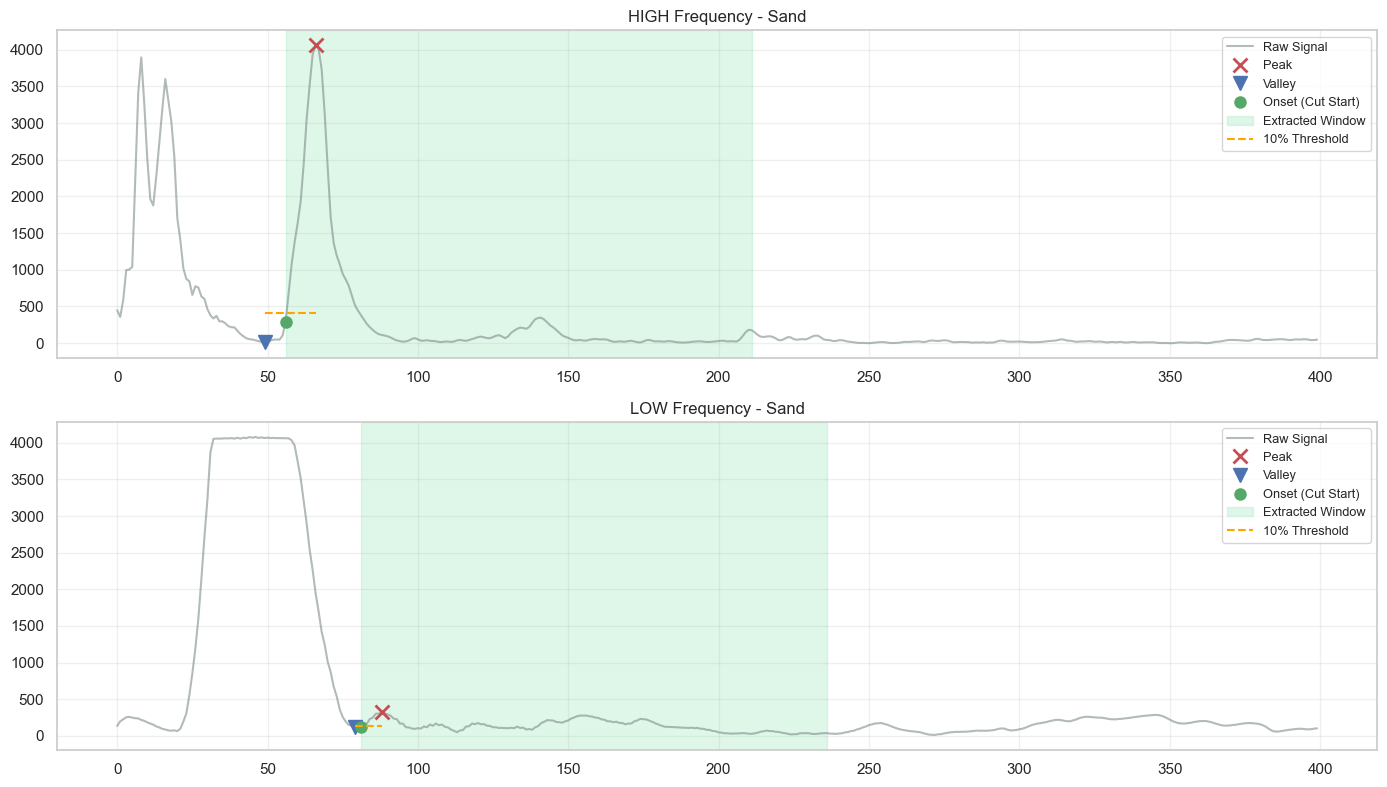

In [ ]:
# 1. Daten laden (falls noch nicht da)
if os.path.exists(INPUT_TRAIN):
    # Jetzt mit data_lf!
    X_train_raw, Y_train, raw_hf, raw_lf = load_and_extract(
        INPUT_TRAIN, WINDOW_LEN)
    if os.path.exists(INPUT_TEST):
        X_test_raw, Y_test, _, _ = load_and_extract(INPUT_TEST, WINDOW_LEN)
else:
    raise FileNotFoundError("Keine Daten gefunden.")

# 2. Visualisierung A: Exemplarisches Sample (High & Low)
sample_idx = 0  # Wir nehmen das erste Sample (kannst du ändern)
label_name = Y_train[sample_idx]

print(
    f"\n--- Visualisierung A: Detail-Analyse Sample {sample_idx} ({label_name}) ---")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# High Frequency (Mask 30, Start 20)
plot_signal_details(axes[0], raw_hf[sample_idx], WINDOW_LEN, 30, 20,
                    f"HIGH Frequency - {label_name}")

# Low Frequency (Mask 78, Start 55 - andere Parameter!)
plot_signal_details(axes[1], raw_lf[sample_idx], WINDOW_LEN, 78, 55,
                    f"LOW Frequency - {label_name}")

plt.tight_layout()
plt.show()



--- Visualisierung B: Durchschnittliche Wellenformen pro Klasse ---


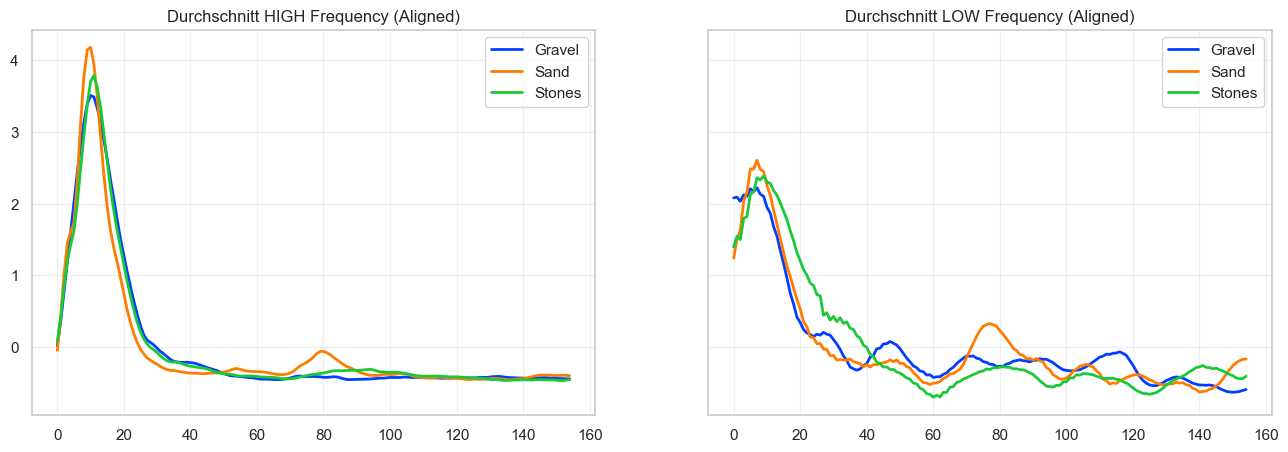

In [18]:

# 3. Visualisierung B: Durchschnittliche Wellenformen (unverändert)
print("\n--- Visualisierung B: Durchschnittliche Wellenformen pro Klasse ---")
classes = np.unique(Y_train)
hf_start, hf_end = 8, 8 + WINDOW_LEN
lf_start, lf_end = 8 + WINDOW_LEN, 8 + 2 * WINDOW_LEN

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
colors = sns.color_palette("bright", len(classes))

for i, cls in enumerate(classes):
    mask = (Y_train == cls)
    mean_hf = np.mean(X_train_raw[mask, hf_start:hf_end], axis=0)
    mean_lf = np.mean(X_train_raw[mask, lf_start:lf_end], axis=0)

    axes[0].plot(mean_hf, label=cls, color=colors[i], linewidth=2)
    axes[1].plot(mean_lf, label=cls, color=colors[i], linewidth=2)

axes[0].set_title("Durchschnitt HIGH Frequency (Aligned)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].set_title("Durchschnitt LOW Frequency (Aligned)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.show()

## Training

In [19]:
# Feature Split
NUM_STATS = 8
X_stats_train = X_train_raw[:, :NUM_STATS]
X_wave_train = X_train_raw[:, NUM_STATS:]
X_stats_test = X_test_raw[:, :NUM_STATS]
X_wave_test = X_test_raw[:, NUM_STATS:]

# 1. Standardisierung (Z-Score)
scaler = StandardScaler()
X_wave_train_std = scaler.fit_transform(X_wave_train)
X_wave_test_std = scaler.transform(X_wave_test)

# 2. PCA mit genau 24% Varianz
print("Berechne PCA...")
pca = PCA(n_components=0.24, random_state=42)
X_pca_train = pca.fit_transform(X_wave_train_std)
X_pca_test = pca.transform(X_wave_test_std)

print(f"   -> {pca.n_components_} Komponenten erklären {np.sum(pca.explained_variance_ratio_)*100:.1f}% Varianz.")

# Features kombinieren
X_train_final = np.hstack([X_stats_train, X_pca_train])
X_test_final = np.hstack([X_stats_test, X_pca_test])

# 3. Training (Random Forest)
print("Trainiere Random Forest (300 Trees)...")
model = RandomForestClassifier(n_estimators=300,
                               random_state=42,
                               max_features='sqrt',
                               min_samples_leaf=1)
model.fit(X_train_final, Y_train)
print("Training abgeschlossen.")

Berechne PCA...
   -> 2 Komponenten erklären 25.0% Varianz.
Trainiere Random Forest (300 Trees)...
Training abgeschlossen.


GENAUIGKEIT (Testset): 83.3%
Anzahl PCA Komponenten: 2


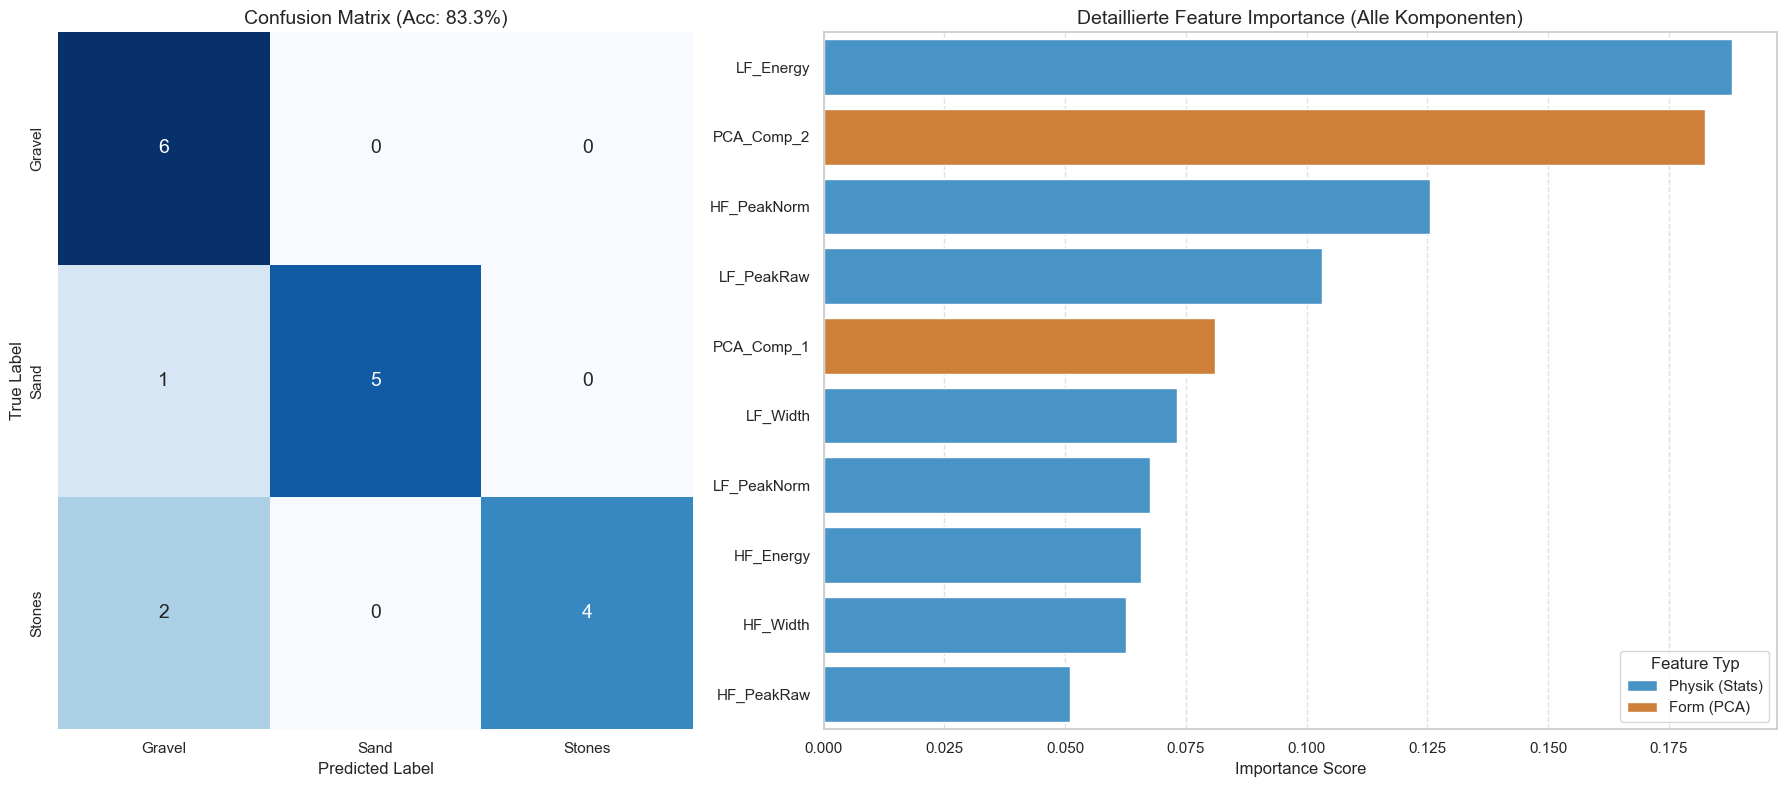

Modell gespeichert als '../../models/advanced_ki.pkl'


In [20]:
# --- ZELLE 6: Evaluation & Detaillierte Feature Importance ---

# 1. Prediction & Accuracy
Y_pred = model.predict(X_test_final)
acc = accuracy_score(Y_test, Y_pred)

print("================================================")
print(f"GENAUIGKEIT (Testset): {acc * 100:.1f}%")
print(f"Anzahl PCA Komponenten: {pca.n_components_}")
print("================================================")

# 2. Daten für den Plot vorbereiten
importances = model.feature_importances_
num_pca = pca.n_components_

# Namen generieren
# 8 Physikalische Stats + N PCA Komponenten
feature_names = ['HF_Energy', 'HF_PeakRaw', 'HF_PeakNorm', 'HF_Width',
                 'LF_Energy', 'LF_PeakRaw', 'LF_PeakNorm', 'LF_Width'] + \
    [f'PCA_Comp_{i+1}' for i in range(num_pca)]

# Typen für die Farbcodierung zuweisen
feature_types = ['Physik (Stats)'] * 8 + ['Form (PCA)'] * num_pca

# DataFrame erstellen und sortieren
df_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
    'Type': feature_types
})

# Sortieren nach Wichtigkeit (Wichtigstes oben)
df_imp = df_imp.sort_values(by='Importance', ascending=False)

# --- DASHBOARD PLOT ---
fig = plt.figure(figsize=(18, 8))
# Rechts etwas breiter für die Balken
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.5])

# Subplot 1: Confusion Matrix
ax1 = fig.add_subplot(gs[0])
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False,
            xticklabels=np.unique(Y_train), yticklabels=np.unique(Y_train),
            annot_kws={"size": 14})
ax1.set_title(f"Confusion Matrix (Acc: {acc*100:.1f}%)", fontsize=14)
ax1.set_xlabel("Predicted Label")
ax1.set_ylabel("True Label")

# Subplot 2: Detailed Feature Importance
ax2 = fig.add_subplot(gs[1])
# Farbpalette definieren: Blau für Physik, Orange für PCA
palette = {'Physik (Stats)': '#3498db', 'Form (PCA)': '#e67e22'}

sns.barplot(x='Importance', y='Feature', hue='Type', data=df_imp, ax=ax2,
            palette=palette, dodge=False)

ax2.set_title(
    "Detaillierte Feature Importance (Alle Komponenten)", fontsize=14)
ax2.set_xlabel("Importance Score")
ax2.set_ylabel("")
ax2.legend(title="Feature Typ", loc='lower right')
ax2.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Speichern
joblib.dump({'model': model, 'pca': pca,
            'scaler': scaler, 'acc': acc}, MODEL_FILE)
print(f"Modell gespeichert als '{MODEL_FILE}'")

=== KLASSIFIZIERUNGS-REPORT ===
              precision    recall  f1-score   support

      Gravel       0.67      1.00      0.80         6
        Sand       1.00      0.83      0.91         6
      Stones       1.00      0.67      0.80         6

    accuracy                           0.83        18
   macro avg       0.89      0.83      0.84        18
weighted avg       0.89      0.83      0.84        18


=== METRIK-TABELLE ===
                  Klasse  Precision  Recall  F1-Score  Anzahl (Support)
                  Gravel      0.667   1.000     0.800                 6
                    Sand      1.000   0.833     0.909                 6
                  Stones      1.000   0.667     0.800                 6
DURCHSCHNITT (Gewichtet)      0.889   0.833     0.836                18


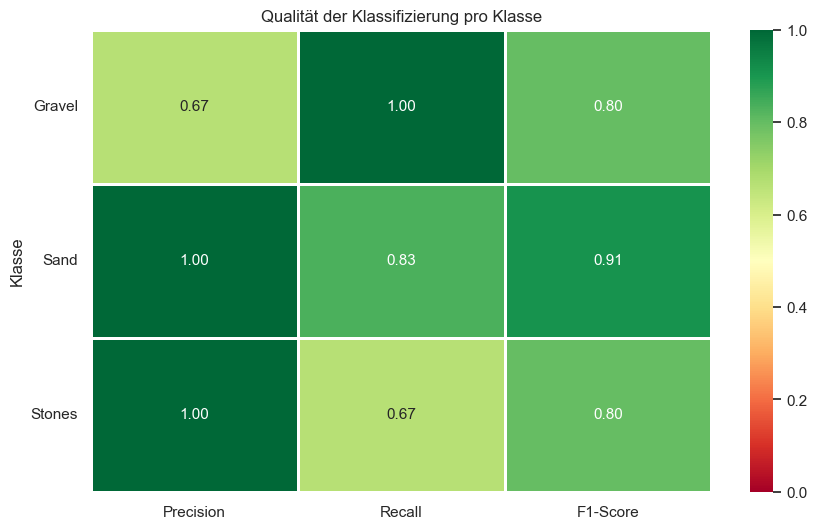

In [21]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

# 1. Vorhersage generieren (falls noch nicht geschehen)
Y_pred = model.predict(X_test_final)

# 2. Detaillierter Text-Bericht
print("=== KLASSIFIZIERUNGS-REPORT ===")
# target_names sorgt dafür, dass die Klassennamen (Sand, Stones, etc.) korrekt angezeigt werden
classes = np.unique(Y_train)
report = classification_report(Y_test, Y_pred, target_names=classes)
print(report)

# 3. Metriken als Tabelle für bessere Lesbarkeit/Visualisierung
precision, recall, f1, support = precision_recall_fscore_support(
    Y_test, Y_pred, average=None, labels=classes)

# DataFrame erstellen
df_metrics = pd.DataFrame({
    'Klasse': classes,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Anzahl (Support)': support
})

# Durchschnittswerte hinzufügen (Weighted Average)
p_avg, r_avg, f1_avg, _ = precision_recall_fscore_support(
    Y_test, Y_pred, average='weighted')
df_avg = pd.DataFrame({
    'Klasse': ['DURCHSCHNITT (Gewichtet)'],
    'Precision': [p_avg],
    'Recall': [r_avg],
    'F1-Score': [f1_avg],
    'Anzahl (Support)': [np.sum(support)]
})

df_metrics_final = pd.concat([df_metrics, df_avg], ignore_index=True)

# Tabelle anzeigen (Runden auf 3 Nachkommastellen)
print("\n=== METRIK-TABELLE ===")
print(df_metrics_final.round(3).to_string(index=False))

# 4. Visualisierung der Metriken als Heatmap
plt.figure(figsize=(10, 6))
# Wir nehmen nur die Klassen (ohne Durchschnitt) für den Plot
sns.heatmap(df_metrics.set_index('Klasse')[['Precision', 'Recall', 'F1-Score']],
            annot=True, cmap='RdYlGn', fmt='.2f', vmin=0, vmax=1, linewidths=1)
plt.title('Qualität der Klassifizierung pro Klasse')
plt.yticks(rotation=0)
plt.show()

Berechne Metriken für Vergleich...
Accuracy Training: 100.0%
Accuracy Test:     83.3%
WARNUNG: Hohes Overfitting (Gap: 16.7%)! Das Modell lernt auswendig.


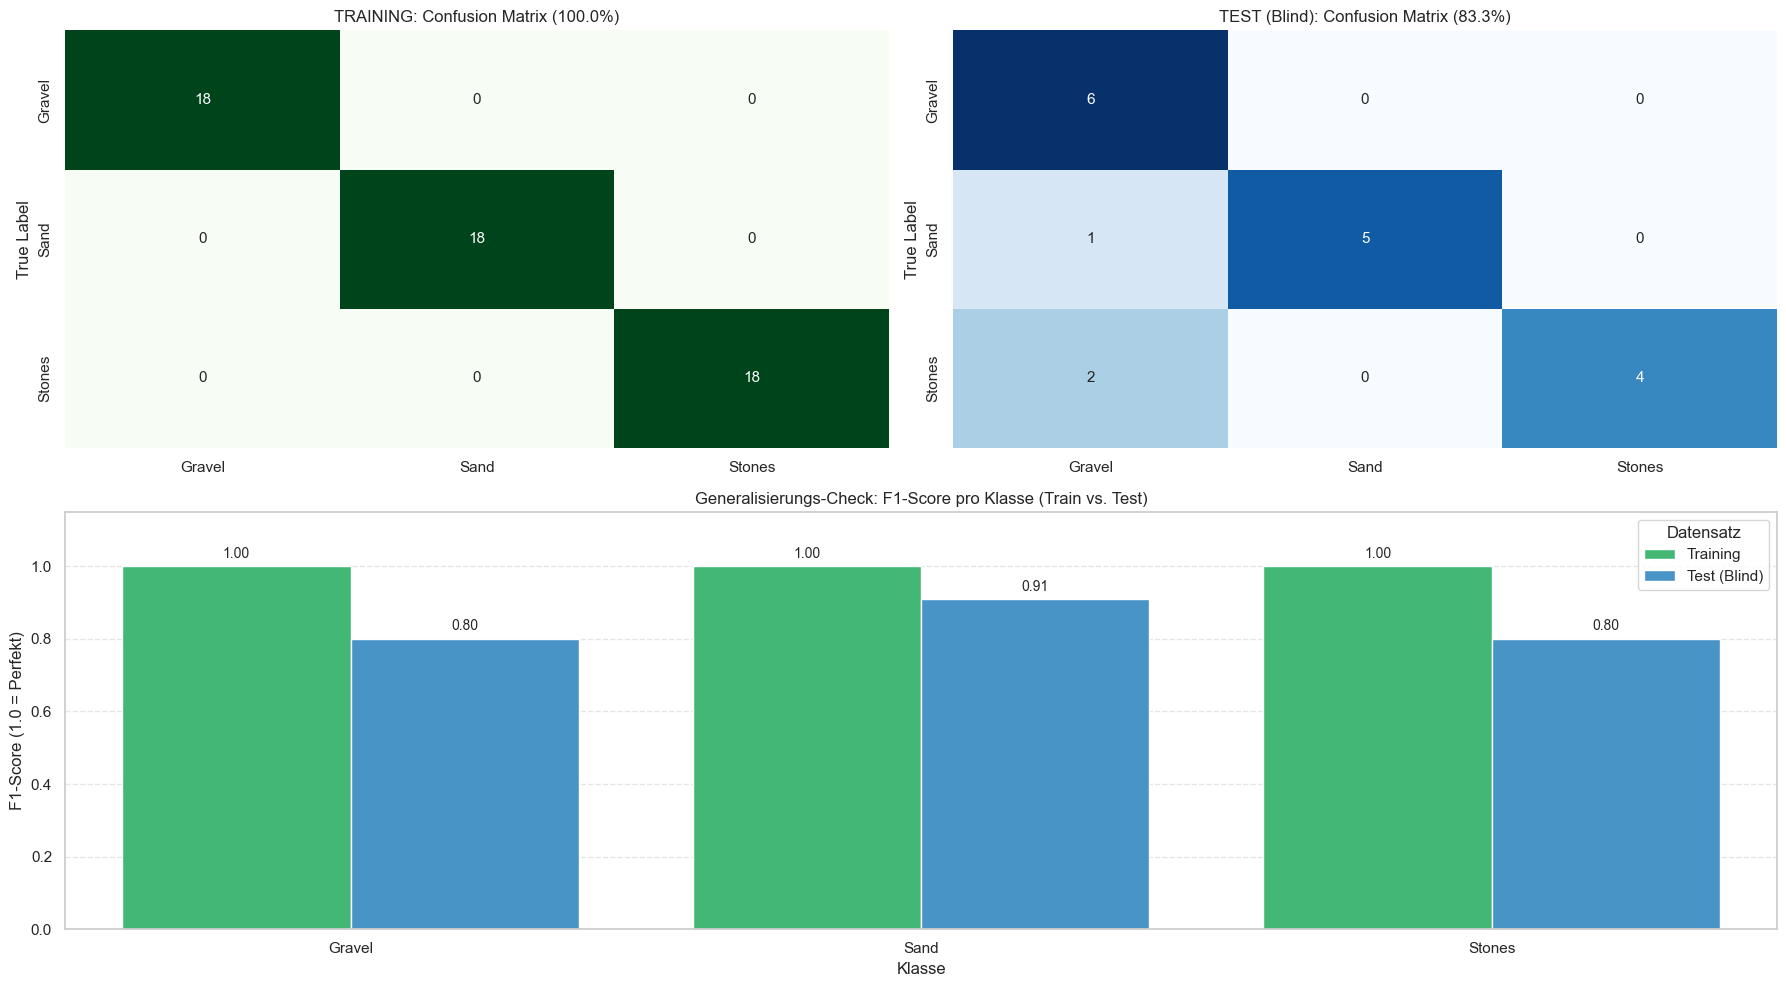

In [22]:
# --- ZELLE 7: Vergleich Training vs. Test (Overfitting Check) ---

# 1. Vorhersagen für BEIDE Datensätze
from sklearn.metrics import f1_score
print("Berechne Metriken für Vergleich...")
Y_pred_train = model.predict(X_train_final)
Y_pred_test = model.predict(X_test_final)

# 2. Metriken berechnen
acc_train = accuracy_score(Y_train, Y_pred_train)
acc_test = accuracy_score(Y_test, Y_pred_test)

print(f"Accuracy Training: {acc_train*100:.1f}%")
print(f"Accuracy Test:     {acc_test*100:.1f}%")
gap = acc_train - acc_test
if gap > 0.15:
    print(
        f"WARNUNG: Hohes Overfitting (Gap: {gap*100:.1f}%)! Das Modell lernt auswendig.")
elif gap < 0.05:
    print(f"GUT: Das Modell generalisiert sehr gut (Gap: {gap*100:.1f}%).")

# 3. Detaillierte F1-Scores pro Klasse holen
# average=None gibt den Score pro Klasse zurück
f1_train = f1_score(Y_train, Y_pred_train, average=None)
f1_test = f1_score(Y_test, Y_pred_test, average=None)
classes = np.unique(Y_train)

# DataFrame für den Plot bauen
df_compare = pd.DataFrame({
    'Klasse': np.tile(classes, 2),
    'F1-Score': np.concatenate([f1_train, f1_test]),
    'Datensatz': ['Training'] * len(classes) + ['Test (Blind)'] * len(classes)
})

# --- VISUALISIERUNG ---
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2)

# Plot A: Confusion Matrix TRAINING
ax1 = fig.add_subplot(gs[0, 0])
cm_train = confusion_matrix(Y_train, Y_pred_train)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', ax=ax1, cbar=False,
            xticklabels=classes, yticklabels=classes)
ax1.set_title(f"TRAINING: Confusion Matrix ({acc_train*100:.1f}%)")
ax1.set_ylabel("True Label")

# Plot B: Confusion Matrix TEST
ax2 = fig.add_subplot(gs[0, 1])
cm_test = confusion_matrix(Y_test, Y_pred_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False,
            xticklabels=classes, yticklabels=classes)
ax2.set_title(f"TEST (Blind): Confusion Matrix ({acc_test*100:.1f}%)")
ax2.set_ylabel("True Label")

# Plot C: F1-Score Vergleich (Balkendiagramm)
ax3 = fig.add_subplot(gs[1, :])
sns.barplot(data=df_compare, x='Klasse', y='F1-Score', hue='Datensatz',
            palette={'Training': '#2ecc71', 'Test (Blind)': '#3498db'}, ax=ax3)

# Werte über die Balken schreiben
for p in ax3.patches:
    if p.get_height() > 0:
        ax3.annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9),
                     textcoords='offset points', fontsize=10)

ax3.set_ylim(0, 1.15)  # Etwas Platz oben lassen
ax3.set_title("Generalisierungs-Check: F1-Score pro Klasse (Train vs. Test)")
ax3.set_ylabel("F1-Score (1.0 = Perfekt)")
ax3.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()